In [15]:
import matplotlib.pyplot as plt
import datetime as dt
import pandas as pd
import numpy as np
import scipy as sp

from pathlib import Path
import soundfile as sf
import json
import subprocess

In [16]:
import folium

In [17]:
import UBNA_localize_process_GCC__20250505 as localize

In [18]:
HARD_DRIVE_LOC = Path('/Volumes/Elements/UBNA_array_tests2026')
experiment_folder = HARD_DRIVE_LOC / 'recover-20260604'
all_wav_files = list(experiment_folder.glob('STF_*/2026*.WAV'))
all_csv_files = list(experiment_folder.glob('STF_*/2026*.CSV'))
all_wav_files, all_csv_files

([PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_193756.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_200000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_203000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_210000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_213000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_220000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_223000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_230000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260603_233000.WAV'),
  PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_000000.WAV'),


In [19]:
SD_CARD_TO_AUDIOMOTH_NUM = {'STF_026': '014', 'STF_028' : '045', 
                            'STF_057': '015', 'STF_109': '008', 
                            'STF_114': '040', 'STF_053': '032', 
                            'STF_021': '016', 'STF_116': '036', 
                            'STF_060': '004', 'STF_025': '042',  
                            'STF_027': '020',
                            'STF_113': '044', 'STF_030': '012'}
FREQ_UPPER_LIM = 6/8
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [20]:
AUDIOMOTH_AT_PATCHA = {'014':'A1 (top)', '045':'A1 (bottom)',
                       '015':'A4 (top)', '008':'A4 (bottom)',
                       '040':'A7 (top)', '032':'A7 (bottom)'}
AUDIOMOTH_AT_PATCHE = {'016':'E2 (top)', '036':'E2 (bottom)',
                       '004':'E4 (top)', '042':'E4 (bottom)',
                       '020':'E8 (alone)',
                       '044':'E9 (top)', '012':'E9 (bottom)'}

AUDIOMOTH_AT_ALLPATCHES = AUDIOMOTH_AT_PATCHA | AUDIOMOTH_AT_PATCHE

In [21]:
valid_wav_files = []
for wav_file in all_wav_files:
    wave_file_dt = dt.datetime.strptime(wav_file.name, '%Y%m%d_%H%M%S.WAV')
    if wave_file_dt == dt.datetime(2026, 6, 4, 19, 0, 0):
        valid_wav_files += [wav_file]
valid_wav_files

[PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_021/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_028/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_025/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_109/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_057/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_114/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_053/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_116/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_030/20260604_190000.WAV'),
 PosixPath('/Volumes/Elements/UBNA_array_tests2026/recover-20260604/STF_026/20260604_190000.WAV'),
 PosixPath

In [22]:
A1_ground_truth_latlon = [47 + (39.3437 / 60), -(122 + (17.8028 / 60))]
A4_ground_truth_latlon = [47 + (39.3243 / 60), -(122 + (17.8002 / 60))]
A7_ground_truth_latlon = [47 + (39.3061 / 60), -(122 + (17.8012 / 60))]

GROUND_TRUTH_LOCS = {'STF_026': A1_ground_truth_latlon, 'STF_028' : A1_ground_truth_latlon,
                     'STF_057': A4_ground_truth_latlon, 'STF_109': A4_ground_truth_latlon,
                     'STF_114': A7_ground_truth_latlon, 'STF_053': A7_ground_truth_latlon}
GROUND_TRUTH_LOCS

{'STF_026': [47.655728333333336, -122.29671333333333],
 'STF_028': [47.655728333333336, -122.29671333333333],
 'STF_057': [47.655405, -122.29667],
 'STF_109': [47.655405, -122.29667],
 'STF_114': [47.65510166666667, -122.29668666666667],
 'STF_053': [47.65510166666667, -122.29668666666667]}

In [46]:
A_locs_mat_tdoa = np.array([np.concatenate([np.array(A1_ground_truth_latlon), [6.5]]), #A1 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [6.5]]), #A4 BOTTOM
                            np.concatenate([np.array(A4_ground_truth_latlon), [7.5]]), #A4 TOP
                            np.concatenate([np.array(A7_ground_truth_latlon), [6.5]]), #A7 BOTTOM
                            np.concatenate([np.array(A1_ground_truth_latlon), [7.5]])]) #A1 TOP
ref_A_loc = np.concatenate([np.array(A7_ground_truth_latlon), [7.5]])
A_locs_mat_tdoa, ref_A_loc

(array([[  47.65572833, -122.29671333,    6.5       ],
        [  47.655405  , -122.29667   ,    6.5       ],
        [  47.655405  , -122.29667   ,    7.5       ],
        [  47.65510167, -122.29668667,    6.5       ],
        [  47.65572833, -122.29671333,    7.5       ]]),
 array([  47.65510167, -122.29668667,    7.5       ]))

In [47]:
from pyproj import Transformer

# WGS84 longitude/latitude/elevation -> ECEF XYZ meters.
# always_xy=True means transform(lon, lat, height), even though EPSG:4979's
# formal axis order is lat, lon, height.
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)

In [48]:
def latlon_delta_xy_m(lat1, lon1, lat2, lon2):
    R = 6371000
    lat0 = (lat1 + lat2) / 2
    dx = R * np.radians(lon2 - lon1) * np.cos(np.radians(lat0))
    dy = R * np.radians(lat2 - lat1)
    return dx, dy

In [62]:
A_locs_mat_tdoa_meters = np.zeros(A_locs_mat_tdoa.shape)
for channel_num in range(5):
    coords = A_locs_mat_tdoa[channel_num]
    x, y = latlon_delta_xy_m(ref_A_loc[0], ref_A_loc[1], coords[0], coords[1])
    A_locs_mat_tdoa_meters[channel_num] = np.array([x, y, (coords[2] - ref_A_loc[2])])
A_locs_mat_tdoa_meters

array([[-1.9973214 , 69.68215403, -1.        ],
       [ 1.24832974, 33.72912775, -1.        ],
       [ 1.24832974, 33.72912775,  0.        ],
       [ 0.        ,  0.        , -1.        ],
       [-1.9973214 , 69.68215403,  0.        ]])

In [63]:
A_locs_mat_tdoa_meters = A_locs_mat_tdoa_meters[:2,:2]
A_locs_mat_tdoa_meters

array([[-1.9973214 , 69.68215403],
       [ 1.24832974, 33.72912775]])

In [64]:
ref_A_loc_meters = np.array([0, 0])
ref_A_loc_meters

array([0, 0])

In [65]:
x0 = ref_A_loc_meters[0]
y0 = ref_A_loc_meters[1]

In [66]:
NUM_NONREFCHANNELS = 2

In [67]:
xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))

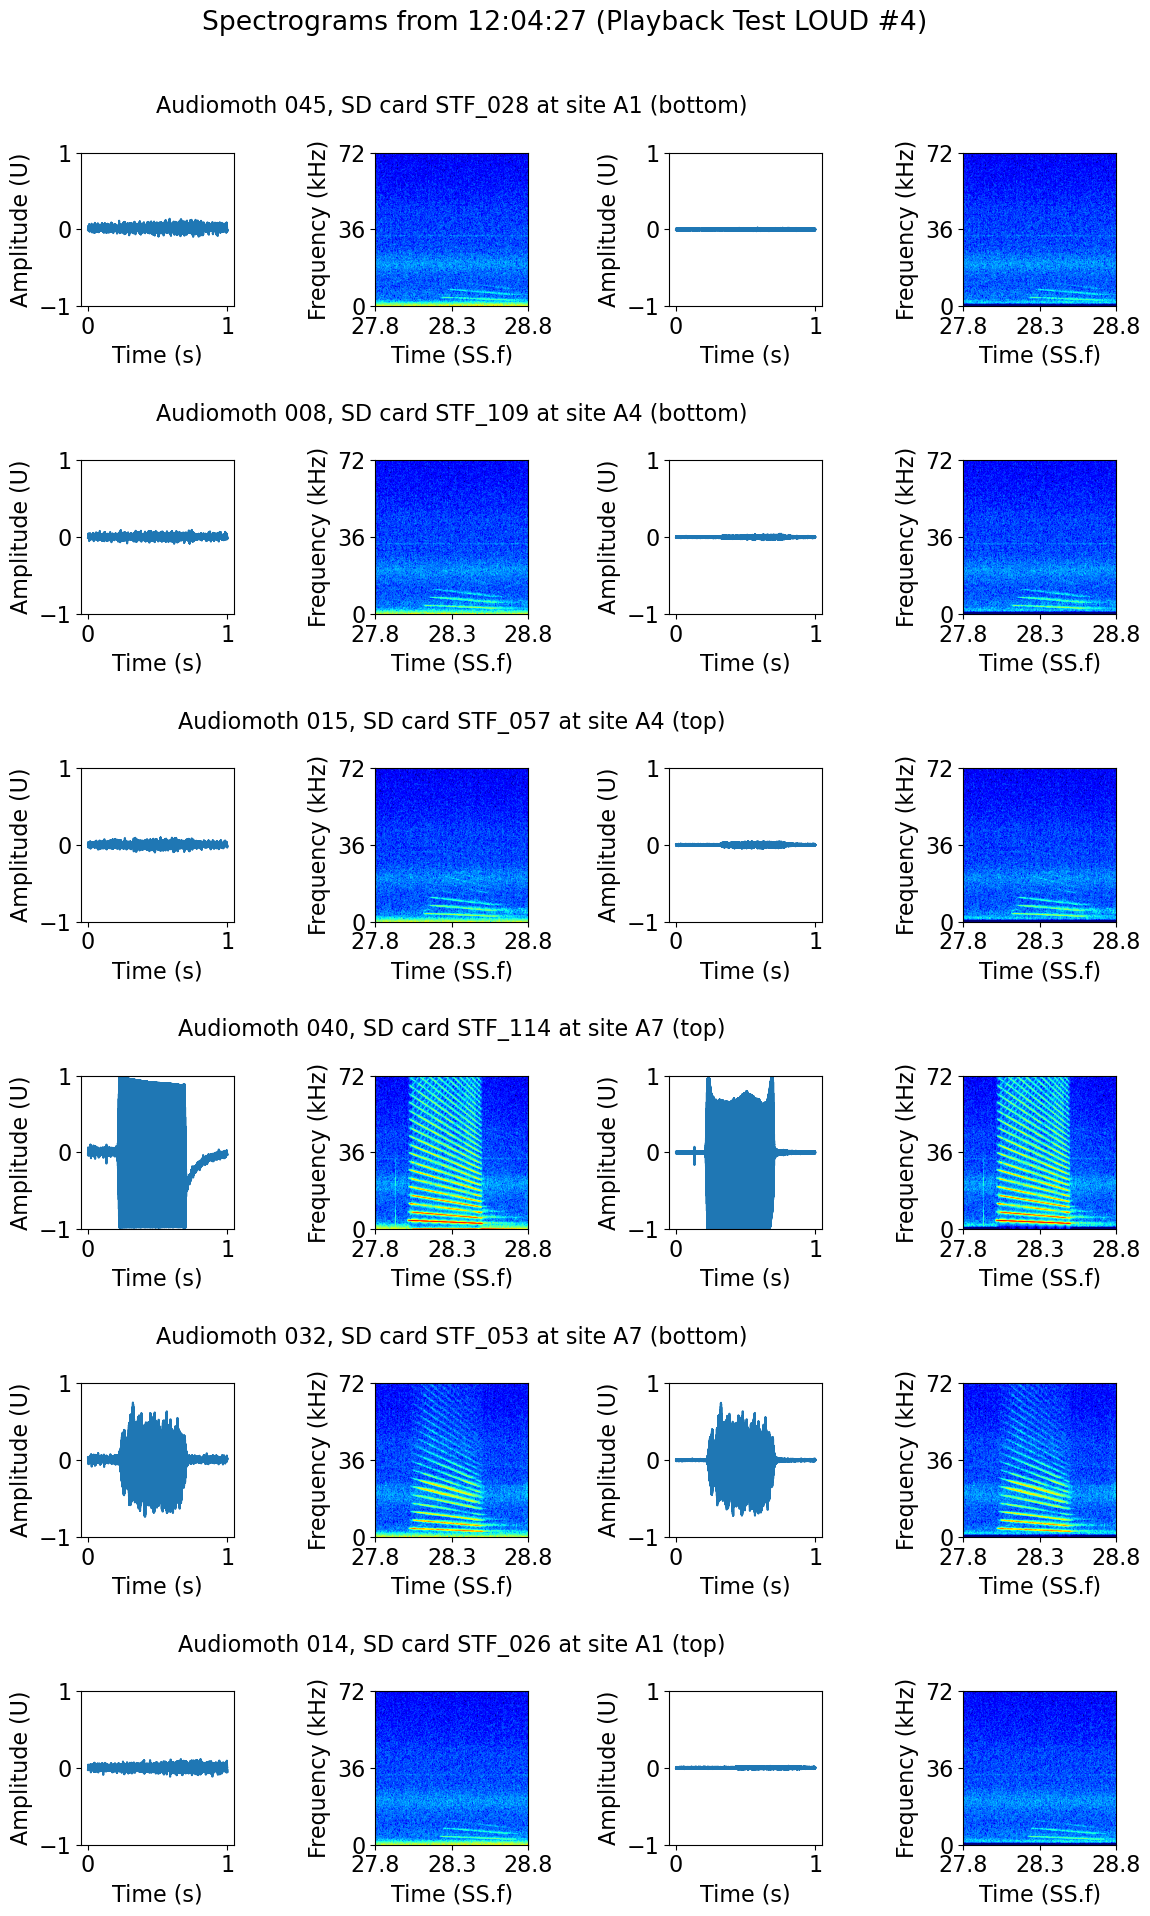

In [68]:
recording_start_dt = dt.datetime(2026, 6, 4, 19, 4, 27, 800000)
recording_start_string = (recording_start_dt - dt.timedelta(hours=7)).strftime('%H:%M:%S')
SAMPLERATE = 192000

fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 4, figsize=(12, 3.2*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Playback Test LOUD #{int(3+1)})', y=1.0)

i = 0
highpassed_audio_segments = dict()
audio_segments = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(int(SAMPLERATE*read_duration_in_secs))
        audio_segments[wav_AUDIOMOTH] = audio_seg
        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        highpassed_audio_segments[wav_AUDIOMOTH] = highpassed_audio_seg

        vmax = 0
        vmin = -100

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 3]
        spec, freqs, t, im = ax.specgram(highpassed_audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 3):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%S.%f"))[:4]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 3), labels=times, rotation=0)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (SS.f)") 

        ax = ax_all[i, 2]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), highpassed_audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        ax = ax_all[i, 1]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", y=1.2, fontsize=16)
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 3):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%S.%f"))[:4]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 3), labels=times, rotation=0)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (SS.f)") 

        ax = ax_all[i, 0]
        ax.plot(np.linspace(0, read_duration_in_secs, read_duration_in_secs*fs), audio_seg)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        i+=1
fig.tight_layout()
plt.show()

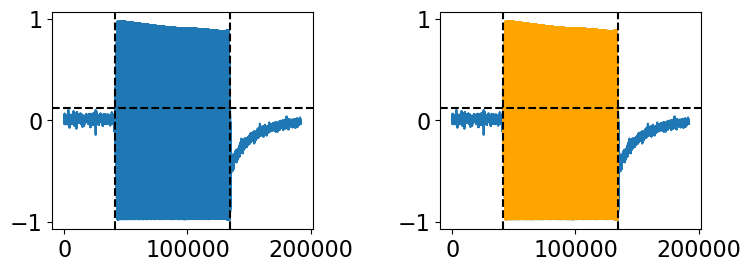

In [69]:
template_signal = audio_segments['040']
fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

threshold = 0.125
first_over_threshold = np.where(template_signal>=threshold)[0][0]
last_over_threshold = np.where(template_signal>=threshold)[0][-1]
relevant_template_signal = template_signal[first_over_threshold:last_over_threshold]

ax = ax_all[0]
ax.plot(template_signal)
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

ax = ax_all[1]
ax.plot(template_signal)
ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_signal, color='orange')
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

fig.tight_layout()
plt.show()

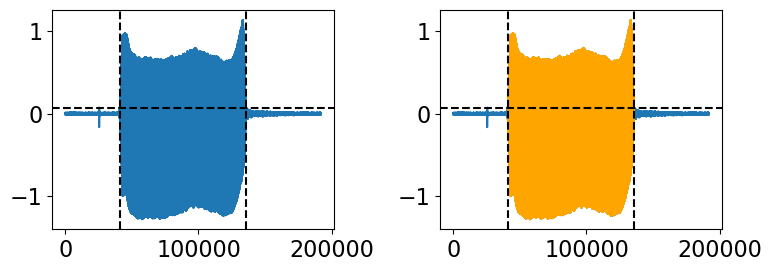

In [70]:
template_highpassed_signal = highpassed_audio_segments['040']
fig, ax_all = plt.subplots(1, 2, figsize=(8, 3))

threshold = 0.075
first_over_threshold = np.where(template_highpassed_signal>=threshold)[0][0]
last_over_threshold = np.where(template_highpassed_signal>=threshold)[0][-1]
relevant_template_highpassed_signal = template_highpassed_signal[first_over_threshold:last_over_threshold]

ax = ax_all[0]
ax.plot(template_highpassed_signal)
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

ax = ax_all[1]
ax.plot(template_highpassed_signal)
ax.plot(np.arange(first_over_threshold, last_over_threshold), relevant_template_highpassed_signal, color='orange')
ax.axhline(y=threshold, linestyle='dashed', color='k')
ax.axvline(x=first_over_threshold, linestyle='dashed', color='k')
ax.axvline(x=last_over_threshold, linestyle='dashed', color='k')

fig.tight_layout()
plt.show()

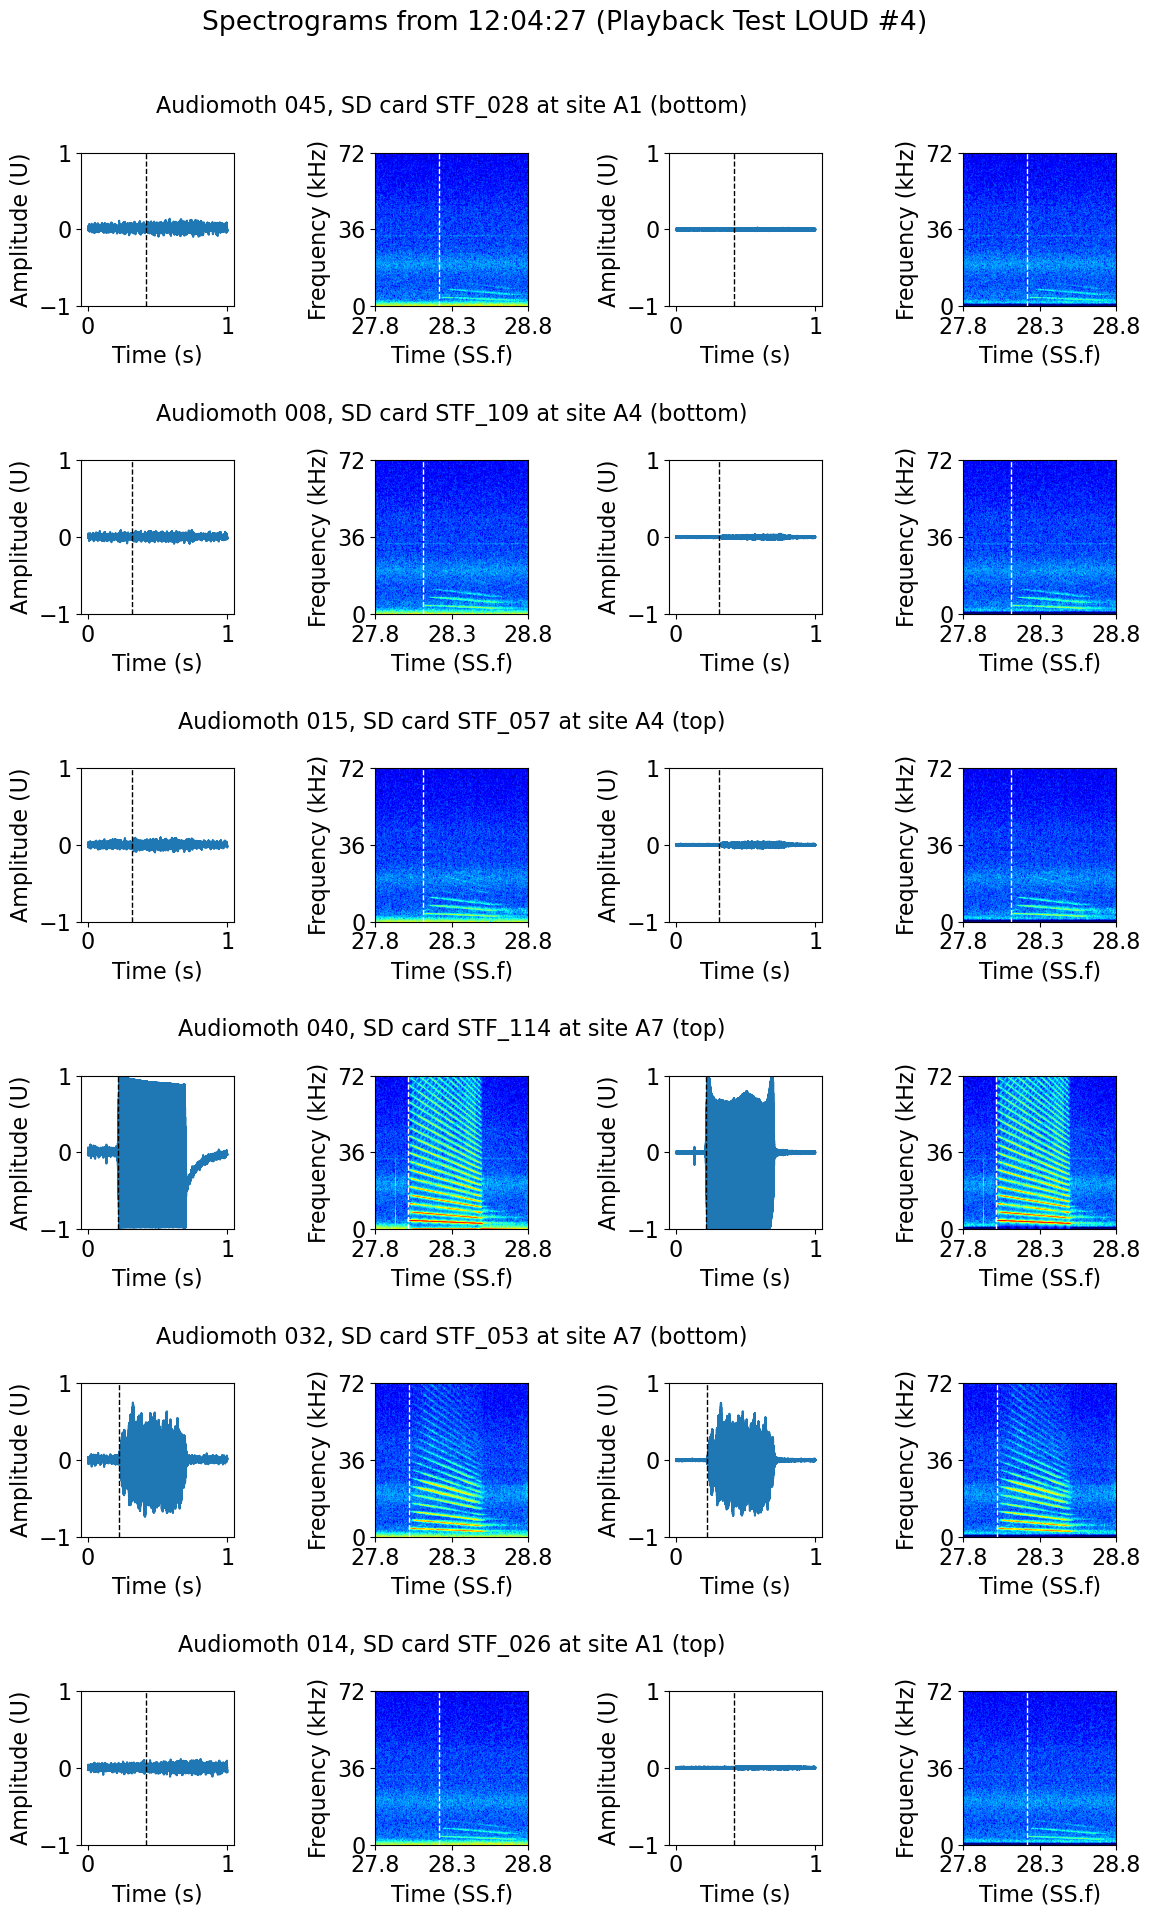

In [71]:
fig, ax_all = plt.subplots(len(AUDIOMOTH_AT_PATCHA), 4, figsize=(12, 3.2*len(AUDIOMOTH_AT_PATCHA)))
plt.rcParams.update({'font.size': 16})
fig.suptitle(f'Spectrograms from {recording_start_string} (Playback Test LOUD #{int(3+1)})', y=1.0)

i = 0
time_delay_in_seconds_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_dictionary = dict()
time_delay_in_seconds_highpassed_matrix = np.zeros(len(AUDIOMOTH_AT_PATCHA))
time_delay_in_seconds_highpassed_dictionary = dict()
for example_wav_file in valid_wav_files:
    wav_SD_card = example_wav_file.parts[-2]
    wav_AUDIOMOTH = SD_CARD_TO_AUDIOMOTH_NUM[wav_SD_card]
    if wav_AUDIOMOTH in AUDIOMOTH_AT_PATCHA.keys():
        example_wav_file_dt = dt.datetime.strptime(example_wav_file.name, '%Y%m%d_%H%M%S.WAV')
        samples_until_recording_start = (recording_start_dt - example_wav_file_dt).total_seconds()
        recorded_audio = sf.SoundFile(example_wav_file)
        read_offset = samples_until_recording_start
        read_duration_in_secs = 1
        num_samples = int(read_duration_in_secs*SAMPLERATE)
        recorded_audio.seek(int(SAMPLERATE*read_offset))
        audio_seg = recorded_audio.read(num_samples)

        signal1 = audio_seg
        signal2 = relevant_template_signal
        cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
        lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / SAMPLERATE
        time_delay_in_seconds_matrix[i] = time_delay_in_seconds
        time_delay_in_seconds_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds

        highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, SAMPLERATE, 1500)
        signal1 = highpassed_audio_seg
        signal2 = relevant_template_highpassed_signal
        cross_correlation = sp.signal.correlate((signal1), (signal2), mode='full')
        lags = sp.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds_highpassed = time_delay_in_samples / SAMPLERATE
        time_delay_in_seconds_highpassed_matrix[i] = time_delay_in_seconds_highpassed
        time_delay_in_seconds_highpassed_dictionary[wav_AUDIOMOTH] = time_delay_in_seconds_highpassed

        vmax = 0
        vmin = -100

        audio_features = dict()
        audio_features['audio_seg'] = audio_seg
        audio_features['sample_rate'] = SAMPLERATE
        audio_features['start'] = read_offset
        audio_features['duration'] = read_duration_in_secs

        spec_features = dict()
        spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = vmin
        spec_features['vmax'] = vmax

        audio_seg = audio_features['audio_seg']
        fs = audio_features['sample_rate']
        start = audio_features['start']
        duration = audio_features['duration']

        vmax = spec_features['vmax']
        vmin = spec_features['vmin']
        cmap = spec_features['cmap']
        nfft = spec_features['NFFT']

        ax = ax_all[i, 3]
        spec, freqs, t, im = ax.specgram(highpassed_audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 3):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%S.%f"))[:4]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 3), labels=times, rotation=0)
        ax.axvline(x=time_delay_in_seconds_highpassed*(fs/2), linestyle='dashed', color='w', linewidth=1)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (SS.f)") 

        ax = ax_all[i, 2]
        ax.plot(np.linspace(0, read_duration_in_secs, num_samples), highpassed_audio_seg)
        ax.axvline(x=time_delay_in_seconds_highpassed, linestyle='dashed', color='k', linewidth=1)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        ax = ax_all[i, 1]
        ax.set_title(f"Audiomoth {wav_AUDIOMOTH}, SD card {wav_SD_card} at site {AUDIOMOTH_AT_ALLPATCHES[wav_AUDIOMOTH]}", y=1.2, fontsize=16)
        spec, freqs, t, im = ax.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
        ax.set_yticks(ticks=np.linspace(0, FREQ_UPPER_LIM, 3), labels=np.linspace(0, FREQ_UPPER_LIM * (fs/2000), 3).astype('int'))
        ax.set_ylim(0, FREQ_UPPER_LIM)
        times = []
        for s in np.linspace(0, duration, 3):
            times += [str(dt.datetime.strftime(recording_start_dt + dt.timedelta(seconds=float(s)), "%S.%f"))[:4]]
        ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), 3), labels=times, rotation=0)
        ax.axvline(x=time_delay_in_seconds*(fs/2), linestyle='dashed', color='w', linewidth=1)
        ax.set_ylabel("Frequency (kHz)")
        ax.set_xlabel("Time (SS.f)") 

        ax = ax_all[i, 0]
        ax.plot(np.linspace(0, read_duration_in_secs, num_samples), audio_seg)
        ax.axvline(x=time_delay_in_seconds, linestyle='dashed', color='k', linewidth=1)
        ax.set_ylabel('Amplitude (U)')
        ax.set_xlabel("Time (s)") 
        ax.set_ylim(-1, 1)

        i+=1
fig.tight_layout()
plt.show()

In [72]:
time_delay_in_seconds_matrix, time_delay_in_seconds_dictionary['040']

(array([0.41965625, 0.31369792, 0.31266146, 0.21569271, 0.22210417,
        0.4171875 ]),
 0.21569270833333334)

In [73]:
time_received_at_rn = time_delay_in_seconds_matrix
t_delay_ref_to_selected_channel = time_delay_in_seconds_dictionary['040']
time_delay_mics_to_selected_ref_channel_temp = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel)
time_delay_mics_to_selected_ref_channel_temp

array([0.20396354, 0.09800521, 0.09696875, 0.        , 0.00641146,
       0.20149479])

In [74]:
time_delay_mics_to_selected_ref_channel = np.array([time_delay_mics_to_selected_ref_channel_temp[5], 
                                                    time_delay_mics_to_selected_ref_channel_temp[2], 
                                                    time_delay_mics_to_selected_ref_channel_temp[3]])
time_delay_mics_to_selected_ref_channel

array([0.20149479, 0.09696875, 0.        ])

In [75]:
IND_OF_SELECTED_CHANNEL = 2
SOUND_SPEED_AIR = 343

In [76]:
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=0)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)
measured_d_mics_to_ref

array([69.11271354, 33.26028125])

In [77]:
NUM_NONREFCHANNELS = 2

In [78]:
measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
measured_dm0_column

array([[69.11271354],
       [33.26028125]])

In [79]:
A_mat = np.hstack(((A_locs_mat_tdoa_meters), measured_dm0_column))
A_mat

array([[-1.9973214 , 69.68215403, 69.11271354],
       [ 1.24832974, 33.72912775, 33.26028125]])

In [80]:
wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (measured_dm0_column**2))/2
wm0

array([[41.51235502],
       [16.48303851]])

In [81]:
xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)
xs[:,0]

array([-1.59993524,  0.20768061,  0.34501812])

In [84]:
measured_dm0_column = measured_d_mics_to_ref.reshape((NUM_NONREFCHANNELS, 1))
num_noise = 1000
dm0_columns = (measured_dm0_column + np.random.normal(loc=0, scale=1e-3, size=(NUM_NONREFCHANNELS, num_noise)))
xs_estimates = np.zeros((num_noise, 3))
for j in range(num_noise):
    dm0_column = dm0_columns[:,j].reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack(((A_locs_mat_tdoa_meters), dm0_column))
    wm0 = ((xm**2 + ym**2) - (x0**2 + y0**2) - (dm0_column**2))/2
    xs, residuals, rank, sing_vals = sp.linalg.lstsq(A_mat, wm0)
    xs_estimates[j,:] = xs[:,0]

mean_xs = np.mean(xs_estimates, axis=0)
mean_xs.reshape((1,3))

array([[-1.59948943,  0.20769693,  0.34500219]])

In [85]:
SD_CARD_TO_AUDIOMOTH_NUM

{'STF_026': '014',
 'STF_028': '045',
 'STF_057': '015',
 'STF_109': '008',
 'STF_114': '040',
 'STF_053': '032',
 'STF_021': '016',
 'STF_116': '036',
 'STF_060': '004',
 'STF_025': '042',
 'STF_027': '020',
 'STF_113': '044',
 'STF_030': '012'}

In [86]:
AUDIOMOTH_AT_PATCHA

{'014': 'A1 (top)',
 '045': 'A1 (bottom)',
 '015': 'A4 (top)',
 '008': 'A4 (bottom)',
 '040': 'A7 (top)',
 '032': 'A7 (bottom)'}

In [87]:
AUDIOMOTH_AT_PATCHE

{'016': 'E2 (top)',
 '036': 'E2 (bottom)',
 '004': 'E4 (top)',
 '042': 'E4 (bottom)',
 '020': 'E8 (alone)',
 '044': 'E9 (top)',
 '012': 'E9 (bottom)'}

In [89]:
audiomoth_to_color = {'014':'green', '045':'green',
                       '015':'red', '008':'red',
                       '040':'yellow', '032':'yellow',
                       '016':'blue', '036':'blue',
                       '004':'orange', '042':'orange',
                       '020':'pink',
                       '044':'brown', '012':'brown'}